# AE 498 PDR — 2024 PDC25 Kinetic Impactor Mission Design

**Pipeline:**
1. Run GRSS once → daily asteroid states from epoch to impact
2. SPICE → daily Earth states
3. Lambert sweep → porkchop plot (C3 vs departure/arrival)
4. Pick best dates → compute v_rel, ΔV to asteroid
5. B-plane before/after deflection

## Cell 1 — Imports & Constants

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import spiceypy as spice
from astropy.time import Time
from grss import libgrss, utils, prop
import grss

# ── Constants ────────────────────────────────────────────────
AU_KM   = 149597870.7          # km per au
AU_M    = 1.49597870700e11     # metres per AU
DAY_S   = 86400.0              # seconds per day
R_e_km  = 6371.0               # Earth radius km
R_earth = R_e_km / AU_KM       # Earth radius AU
MU_SUN  = 1.32712440018e11 / AU_KM**3 * DAY_S**2   # AU³/day²
MU_EARTH_KMS = 3.986004418e5   # km³/s²
J2000_MJD = 51544.5            # MJD of J2000 epoch


MASS_KG   = 3.93e9
RADIUS_AU = 0.075 / AU_KM

def et_to_mjd(et):  return J2000_MJD + et / DAY_S
def mjd_to_et(mjd): return (mjd - J2000_MJD) * DAY_S

print('Imports OK')
print(f'MU_SUN = {MU_SUN:.6e} au³/day²')

Imports OK
MU_SUN = 2.959122e-04 au³/day²


## Cell 2 — Load SPICE Kernels & OD Solution

In [2]:
# Load SPICE kernels (same as your working code)
spice.furnsh('naif0012.tls')
spice.furnsh('2024_PDC25a-s3-merged-DE441.bsp')
print('SPICE kernels loaded')

# Load OD solution
with open('./data/sol.json', 'r') as f:
    sol = json.load(f)
print('OD solution loaded')
print(f"  Epoch MJD = {sol['t']:.4f}")
for k,v in sol.items():
    print(f'  {k:6s} = {v:.10e}')

SPICE kernels loaded
OD solution loaded
  Epoch MJD = 61002.0000
  t      = 6.1002000000e+04
  e      = 3.9039777299e-01
  q      = 1.0059188243e+00
  tp     = 6.1214636873e+04
  om     = 3.7422838533e+00
  w      = 6.2821620106e+00
  i      = 1.8651518237e-01
  a2     = 1.0043516623e-13


## Cell 3 — Run GRSS Once: Asteroid Daily States from Epoch to Impact

This is the key cell. We propagate the nominal asteroid once and save every day's state.
Then we can interpolate to get asteroid position at **any** arrival date — no need to re-run GRSS for each Lambert call.

In [3]:
from grss import prop, utils
import json
import numpy as np
import spiceypy as spice
from astropy.time import Time

# ── Constants ─────────────────────────────────────────────────
AU_KM     = 149597870.7
DAY_S     = 86400.0
J2000_MJD = 51544.5
MU_SUN    = 1.32712440018e11 / AU_KM**3 * DAY_S**2

def et_to_mjd(et):  return J2000_MJD + et / DAY_S
def mjd_to_et(mjd): return (mjd - J2000_MJD) * DAY_S

# ── Load OD solution ──────────────────────────────────────────
with open('./data/sol.json', 'r') as f:
    init_sol = json.load(f)

nongrav_info = {
    'a1'    : 0.0,
    'a2'    : init_sol['a2'],
    'a3'    : 0.0,
    'alpha' : 1.0,
    'k'     : 0.0,
    'm'     : 2.0,
    'n'     : 0.0,
    'r0_au' : 1.0,
    'radius': 75.0,
}

mjd_end   = Time('2041-04-25', scale='tdb', format='iso').tdb.mjd

from grss import libgrss

# ── Use GRSS's own cometary→cartesian conversion ─────────────
# cometaryState = [e, q, tp, om, w, i]  (angles in radians, tp in MJD)
cometary_state = [
    init_sol['e'],
    init_sol['q'],
    init_sol['tp'],
    init_sol['om'],
    init_sol['w'],
    init_sol['i'],
]
cart = libgrss.cometary_to_cartesian(init_sol['t'], cometary_state)
r0 = cart[:3]
v0 = cart[3:]

print(f'r0 = {r0}')
print(f'v0 = {v0}')

# ── Build NongravParameters ───────────────────────────────────
ng = prop.NongravParameters()
ng.a1    = nongrav_info['a1']
ng.a2    = nongrav_info['a2']
ng.a3    = nongrav_info['a3']
ng.alpha = nongrav_info['alpha']
ng.k     = nongrav_info['k']
ng.m     = nongrav_info['m']
ng.n     = nongrav_info['n']
ng.r0_au = nongrav_info['r0_au']

# ── IntegBody + PropSimulation (matching working code exactly) ─
n_days   = int(mjd_end - init_sol['t']) + 1
t_eval   = [init_sol['t'] + i for i in range(n_days)]
t_eval_mjd = np.array(t_eval)
mjd_start  = t_eval_mjd[0]

body = prop.IntegBody(
    '2024PDC25', init_sol['t'], 0.0, 0.0,
    list(r0), list(v0), ng
)

sim = prop.PropSimulation(
    '2024PDC25_prop', init_sol['t'], 440, utils.default_kernel_path
)
sim.set_integration_parameters(mjd_end, t_eval, False, False, False)
sim.add_integ_body(body)

print(f'Running GRSS daily propagation ({n_days} days)...')
sim.integrate()
print('Done.')

ast_states = np.array(sim.xIntegEval)
print(f'Stored {ast_states.shape[0]} daily states')

r0 = [0.44206006342998627, 1.8910912676327196, -0.24724375617573235]
v0 = [-0.010938519551098385, -0.0015716339621881167, -0.0009220449094127083]
Running GRSS daily propagation (5633 days)...
Done.
Stored 5633 daily states


## Cell 4 — Lambert Solver (Curtis Algorithm 5.2)

In [4]:
def stumpff_S(z):
    if   z >  0: return (np.sqrt(z) - np.sin(np.sqrt(z))) / z**1.5
    elif z <  0: return (np.sinh(np.sqrt(-z)) - np.sqrt(-z)) / (-z)**1.5
    else:        return 1.0/6.0

def stumpff_C(z):
    if   z >  0: return (1 - np.cos(np.sqrt(z))) / z
    elif z <  0: return (np.cosh(np.sqrt(-z)) - 1) / (-z)
    else:        return 0.5

def lambert(R1, R2, t, string='pro', mu=MU_SUN):
    """
    Curtis Algorithm 5.2 Lambert solver.
    R1, R2: position vectors [AU]
    t     : time of flight [days]
    Returns V1, V2 [AU/day]
    """
    R1 = np.array(R1, dtype=float)
    R2 = np.array(R2, dtype=float)
    r1 = np.linalg.norm(R1)
    r2 = np.linalg.norm(R2)
    c12 = np.cross(R1, R2)
    theta = np.arccos(np.clip(np.dot(R1, R2) / (r1 * r2), -1, 1))
    if string == 'pro':
        if c12[2] < 0: theta = 2*np.pi - theta
    elif string == 'retro':
        if c12[2] >= 0: theta = 2*np.pi - theta

    A = np.sin(theta) * np.sqrt(r1*r2 / (1 - np.cos(theta)))

    def y(z):
        return r1 + r2 + A*(z*stumpff_S(z) - 1) / np.sqrt(stumpff_C(z))

    def F(z, dt):
        return (y(z)/stumpff_C(z))**1.5 * stumpff_S(z) + A*np.sqrt(y(z)) - np.sqrt(mu)*dt

    def dFdz(z):
        if z == 0:
            return (np.sqrt(2)/40 * y(0)**1.5 +
                    A/8 * (np.sqrt(y(0)) + A*np.sqrt(1/(2*y(0)))))
        else:
            return ((y(z)/stumpff_C(z))**1.5 *
                    (1/(2*z) * (stumpff_C(z) - 3*stumpff_S(z)/(2*stumpff_C(z))) +
                     3*stumpff_S(z)**2/(4*stumpff_C(z))) +
                    A/8 * (3*(stumpff_S(z)/stumpff_C(z))*np.sqrt(y(z)) +
                           A*np.sqrt(stumpff_C(z)/y(z))))

    z = -100.0
    while F(z, t) < 0 if y(z) > 0 else True:
        z += 0.1

    tol = 1e-8; nmax = 5000; ratio = 1.0; n = 0
    while abs(ratio) > tol and n <= nmax:
        n += 1
        ratio = F(z, t) / dFdz(z)
        z -= ratio

    f    = 1 - y(z)/r1
    g    = A * np.sqrt(y(z)/mu)
    gdot = 1 - y(z)/r2
    V1 = (R2 - f*R1) / g
    V2 = (gdot*R2 - R1) / g
    return V1, V2

print('Lambert solver defined')

Lambert solver defined


## Cell 5 — Helper: Interpolate Asteroid & Earth States at Any MJD

In [5]:
# SPICE query constants — add these to Cell 2
FRAME    = 'ECLIPJ2000'
ABCORR   = 'NONE'
OBSERVER = 'SUN'

def asteroid_state_at(mjd):
    et = mjd_to_et(mjd)
    state, _ = spice.spkezr('-937020', et, 'ECLIPJ2000', 'NONE', 'SUN')
    r = np.array(state[:3]) / AU_KM
    v = np.array(state[3:]) / AU_KM * DAY_S
    return r, v

def earth_state_at(mjd):
    """
    Earth heliocentric state from SPICE at given MJD.
    Returns r [AU], v [AU/day]
    """
    et = mjd_to_et(mjd)
    state, _ = spice.spkezr('EARTH', et, FRAME, ABCORR, OBSERVER)
    r = np.array(state[:3]) / AU_KM
    v = np.array(state[3:]) / AU_KM * DAY_S
    return r, v



## Cell 6 — Porkchop Plot: Sweep Departure × Arrival Dates

In [6]:
# ── Sweep parameters ─────────────────────────────────────────
# Departure window: 2037-01-01 to 2040-01-01
# Arrival window  : departure + 30 days to departure + 600 days
# (asteroid impact is April 24 2041 — intercept must be before that)

mjd_impact = et_to_mjd(spice.str2et('2041-04-24 15:24:50'))
print(f'Impact MJD = {mjd_impact:.4f}')

depart_start = et_to_mjd(spice.str2et('2030-01-01 00:00:00'))
depart_end   = et_to_mjd(spice.str2et('2035-06-01 00:00:00'))
depart_step  = 5   # days  (5-day grid for speed)

tof_min = 60    # days
tof_max = 700   # days
tof_step = 5    # days

depart_dates = np.arange(depart_start, depart_end,  depart_step)
tof_values   = np.arange(tof_min,     tof_max+1,    tof_step)

print(f'Departure dates: {len(depart_dates)} points  ({depart_step}-day step)')
print(f'TOF values     : {len(tof_values)} points  ({tof_step}-day step)')
print(f'Total Lambert calls: {len(depart_dates)*len(tof_values):,}')

# ── Allocate result grids ─────────────────────────────────────
C3_grid   = np.full((len(tof_values), len(depart_dates)), np.nan)  # km²/s²
vrel_grid = np.full((len(tof_values), len(depart_dates)), np.nan)  # km/s

# ── Sweep ─────────────────────────────────────────────────────
print('\nRunning porkchop sweep...')
for j, t_dep in enumerate(depart_dates):
    r_earth_dep, v_earth_dep = earth_state_at(t_dep)

    for i, tof in enumerate(tof_values):
        t_arr = t_dep + tof

        # Must arrive before impact
        if t_arr >= mjd_impact - 30:
            continue
        # Must be within our GRSS data range
        if t_arr > t_eval_mjd[-1] or t_arr < t_eval_mjd[0]:
            continue

        r_ast_arr, v_ast_arr = asteroid_state_at(t_arr)

        try:
            V1_sc, V2_sc = lambert(r_earth_dep, r_ast_arr, tof)
        except Exception:
            continue

        # C3 = launch energy [km²/s²]
        dv_launch = V1_sc - v_earth_dep
        C3 = (np.linalg.norm(dv_launch) * AU_KM / DAY_S)**2

        # v_rel at asteroid [km/s]
        dv_impact = V2_sc - v_ast_arr
        v_rel = np.linalg.norm(dv_impact) * AU_KM / DAY_S

        C3_grid[i, j]   = C3
        vrel_grid[i, j] = v_rel

print('Sweep complete.')
valid = np.isfinite(C3_grid)
print(f'Valid solutions: {valid.sum():,} / {C3_grid.size:,}')
if valid.sum() > 0:
    print(f'C3 range : {np.nanmin(C3_grid):.2f} – {np.nanmax(C3_grid[C3_grid < 200]):.2f} km²/s²')
    print(f'v_rel range: {np.nanmin(vrel_grid):.2f} – {np.nanmax(vrel_grid[vrel_grid < 50]):.2f} km/s')
# ── Save porkchop data to file ────────────────────────────────
porkchop_data = {
    'depart_dates': depart_dates.tolist(),   # MJD
    'tof_values':   tof_values.tolist(),     # days
    'C3_grid':      C3_grid.tolist(),        # km²/s²
    'vrel_grid':    vrel_grid.tolist(),      # km/s
    'mjd_impact':   mjd_impact,
}

with open('./data/porkchop_1.json', 'w') as f:
    json.dump(porkchop_data, f)

print(f'Saved porkchop data to ./data/porkchop_1.json')

Impact MJD = 66633.6430
Departure dates: 396 points  (5-day step)
TOF values     : 129 points  (5-day step)
Total Lambert calls: 51,084

Running porkchop sweep...
Sweep complete.
Valid solutions: 51,084 / 51,084
C3 range : 12.02 – 199.93 km²/s²
v_rel range: 1.03 – 49.99 km/s
Saved porkchop data to ./data/porkchop_1.json


Loaded porkchop: (129, 396) grid
b_coll = 1.7059 R⊕
Asteroid mass = 3.3576e+09 kg
S/C mass      = 4000 kg,  β = 3.5
v_rel filter  : >= 7.0 km/s

Valid grid points to propagate: 1,281
(filtered out v_rel < 7.0 km/s and C3 > 60.0 km²/s²)

Running b-plane sweep...
Parallel propagation took 00 minute(s) and 0.350291 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.039745 seconds
Parallel propagation took 00 minute(s) and 0.083575 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.005466 seconds
Parallel propagation took 00 minute(s) and 0.074953 seconds


...

Reconstruction took 00 minute(s) and 0.003269 seconds
Parallel propagation took 00 minute(s) and 0.061381 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.003715 seconds
Parallel propagation took 00 minute(s) and 0.060397 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.004330 seconds

Sweep complete. 1281 points evaluated.
Successful deflections: 379 / 1281  (29.6%)
Saved ./data/bplane_sweep.json


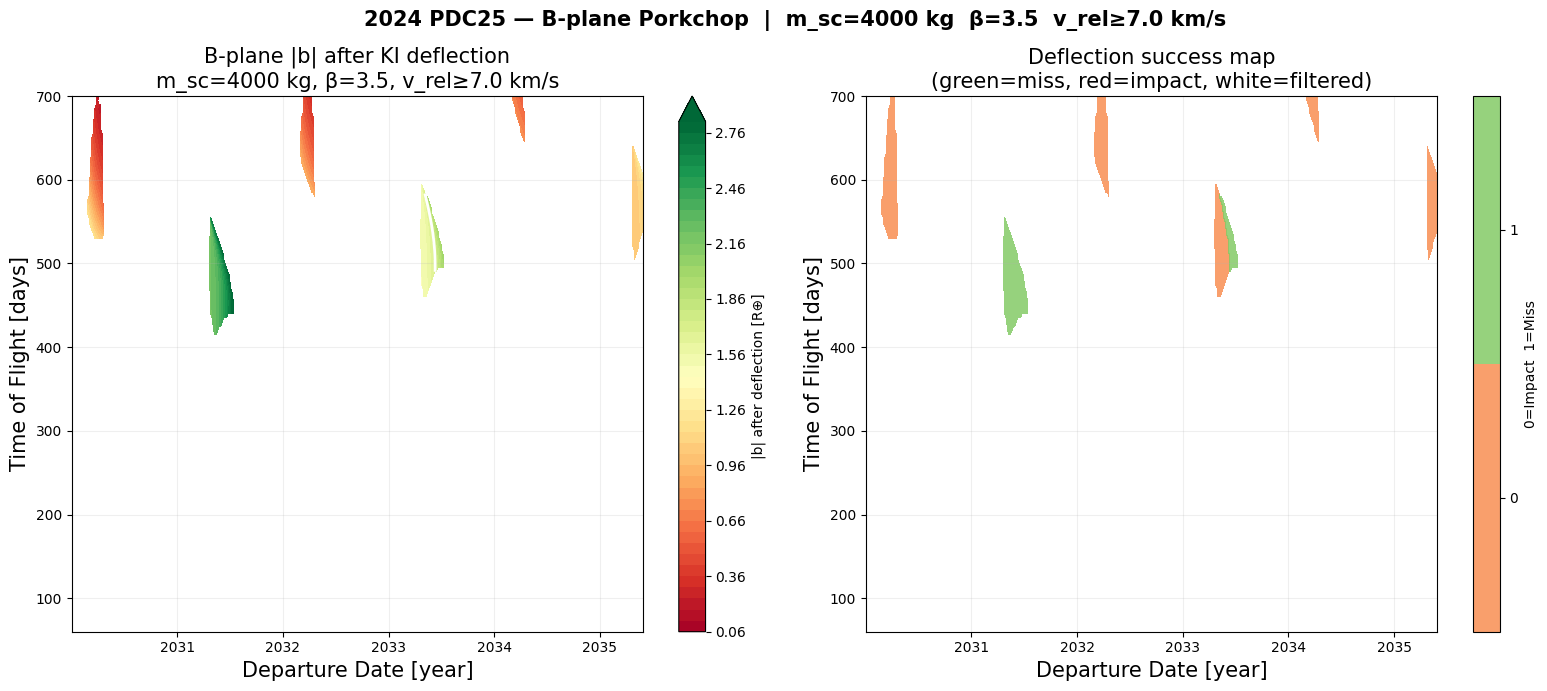

Saved bplane_porkchop.png


In [7]:
import numpy as np
import json
import matplotlib.pyplot as plt
import spiceypy as spice
from astropy.time import Time
from grss import libgrss, utils, prop

# ── Load porkchop data ────────────────────────────────────────
with open('./data/porkchop_1.json', 'r') as f:
    pc = json.load(f)

depart_dates = np.array(pc['depart_dates'])
tof_values   = np.array(pc['tof_values'])
C3_grid      = np.array(pc['C3_grid'])
vrel_grid    = np.array(pc['vrel_grid'])
mjd_impact   = pc['mjd_impact']

print(f'Loaded porkchop: {C3_grid.shape} grid')

# ── Constants ─────────────────────────────────────────────────
AU_KM        = 149597870.7
DAY_S        = 86400.0
R_e_km       = 6371.0
MU_EARTH_KMS = 3.986004418e5

# ── Nominal b-plane ───────────────────────────────────────────
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)
nom        = bp_data['nominal']
U0_kms     = nom['vInf'] * AU_KM / DAY_S
b_coll_km  = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re  = b_coll_km / R_e_km
mjd_impact_nom = nom['t_ca']
print(f'b_coll = {b_coll_Re:.4f} R⊕')

# ── Mission parameters ────────────────────────────────────────
VREL_MIN_KMS = 7.0     # km/s — filter: only keep v_rel >= 7
C3_MAX       = 60.0    # km²/s² — launcher limit
rho_ast      = 1900.0  # kg/m³
R_ast        = 75.0    # m
m_ast        = (4/3) * np.pi * R_ast**3 * rho_ast
m_sc         = 4000.0  # kg
beta_m       = 3.5     # momentum enhancement factor
print(f'Asteroid mass = {m_ast:.4e} kg')
print(f'S/C mass      = {m_sc:.0f} kg,  β = {beta_m}')
print(f'v_rel filter  : >= {VREL_MIN_KMS} km/s')

# ── GRSS nongrav params ───────────────────────────────────────
ng_defl = prop.NongravParameters()
ng_defl.a1    = nongrav_info['a1'];  ng_defl.a1Est = False
ng_defl.a2    = nongrav_info['a2'];  ng_defl.a2Est = True
ng_defl.a3    = nongrav_info['a3'];  ng_defl.a3Est = False
ng_defl.alpha = nongrav_info['alpha']
ng_defl.k     = nongrav_info['k']
ng_defl.m     = nongrav_info['m']
ng_defl.n     = nongrav_info['n']
ng_defl.r0_au = nongrav_info['r0_au']

mjd_end_defl = Time('2060-01-01', scale='tdb', format='iso').tdb.mjd

# ── Helper ────────────────────────────────────────────────────
def get_worst_earth_ca(all_cas):
    earth_cas = [ca for ca in all_cas if ca.centralBody == 'Earth']
    if len(earth_cas) == 0:
        return None
    return min(earth_cas, key=lambda ca: ca.bMag)

# ── Allocate b-plane result grids ─────────────────────────────
bplane_grid   = np.full(C3_grid.shape, np.nan)   # |b| in R⊕
success_grid  = np.full(C3_grid.shape, np.nan)   # 1=miss, 0=impact

# ── Count valid points ────────────────────────────────────────
valid_mask = (
    np.isfinite(C3_grid)         &
    (C3_grid   <= C3_MAX)        &
    (vrel_grid <= VREL_MIN_KMS)
)
n_valid = valid_mask.sum()
print(f'\nValid grid points to propagate: {n_valid:,}')
print(f'(filtered out v_rel < {VREL_MIN_KMS} km/s and C3 > {C3_MAX} km²/s²)\n')

# ── B-plane sweep ─────────────────────────────────────────────
print('Running b-plane sweep...')
count = 0
for j, t_dep in enumerate(depart_dates):
    for i, tof in enumerate(tof_values):

        if not valid_mask[i, j]:
            continue

        t_arr    = t_dep + tof
        v_rel_kms = vrel_grid[i, j]

        # Asteroid state at intercept
        r_ast_int, v_ast_int = asteroid_state_at(t_arr)

        # Re-run Lambert to get v_rel direction
        r_earth_dep, v_earth_dep = earth_state_at(t_dep)
        try:
            V1_sc, V2_sc = lambert(r_earth_dep, r_ast_int, tof)
        except Exception:
            continue

        dv_rel_vec = V2_sc - v_ast_int
        v_rel_hat  = dv_rel_vec / np.linalg.norm(dv_rel_vec)

        # ΔV on asteroid — negative direction (spacecraft pushes asteroid)
        dv_ast_kms    = beta_m * m_sc * v_rel_kms / m_ast
        dv_ast_AUday  = dv_ast_kms / (AU_KM / DAY_S)
        dv_ast_vec    = -dv_ast_AUday * v_rel_hat   # ← correct sign

        # Deflected state
        v_ast_deflected = np.array(v_ast_int) + dv_ast_vec
        cart_defl       = list(r_ast_int) + list(v_ast_deflected)
        try:
            com_defl = libgrss.cartesian_to_cometary(t_arr, cart_defl)
        except Exception:
            continue

        sol_defl = {
            't' : t_arr,
            'e' : com_defl[0], 'q' : com_defl[1], 'tp': com_defl[2],
            'om': com_defl[3], 'w' : com_defl[4], 'i' : com_defl[5],
            'a2': nongrav_info['a2'],
        }

        # Build fresh ref sim for this epoch
        ref_sim = prop.PropSimulation(
            name=f'PDC25_bp_{i}_{j}',
            t0=t_arr,
            defaultSpiceBodies=440,
            DEkernelPath=utils.default_kernel_path
        )
        ref_sim.set_integration_parameters(mjd_end_defl)

        try:
            result = prop.parallel_propagate(
                sol_defl, ng_defl, ref_sim,
                [sol_defl], 1, reconstruct=True
            )
        except Exception:
            continue

        worst = get_worst_earth_ca(result[0][0])
        if worst is None:
            bplane_grid[i, j]  = 999.0   # fully deflected away
            success_grid[i, j] = 1.0
        else:
            b_Re = worst.bMag * AU_KM / R_e_km
            bplane_grid[i, j]  = b_Re
            success_grid[i, j] = 1.0 if b_Re > b_coll_Re else 0.0

        count += 1
        if count % 50 == 0:
            print(f'  {count}/{n_valid} done  '
                  f'({100*count/n_valid:.1f}%)  '
                  f'last |b|={bplane_grid[i,j]:.3f} R⊕')

print(f'\nSweep complete. {count} points evaluated.')
n_success = np.nansum(success_grid == 1.0)
print(f'Successful deflections: {n_success} / {count}  '
      f'({100*n_success/max(count,1):.1f}%)')

# ── Save results ──────────────────────────────────────────────
bp_sweep = {
    'depart_dates' : depart_dates.tolist(),
    'tof_values'   : tof_values.tolist(),
    'bplane_grid'  : bplane_grid.tolist(),
    'success_grid' : success_grid.tolist(),
    'b_coll_Re'    : b_coll_Re,
    'vrel_min'     : VREL_MIN_KMS,
    'C3_max'       : C3_MAX,
    'm_sc'         : m_sc,
    'beta_m'       : beta_m,
}
with open('./data/bplane_sweep.json', 'w') as f:
    json.dump(bp_sweep, f)
print('Saved ./data/bplane_sweep.json')

# ── Plot ──────────────────────────────────────────────────────
def mjd_to_year(mjd):
    return Time(mjd, format='mjd', scale='tdb').decimalyear

depart_years = np.array([mjd_to_year(m) for m in depart_dates])
X, Y = np.meshgrid(depart_years, tof_values)

# Cap |b| for colour scale — anything > 10 R⊕ is a clear miss
bplane_plot = np.copy(bplane_grid)
bplane_plot = np.clip(bplane_plot, 0, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# LEFT — |b| colour map
ax = axes[0]
cf = ax.contourf(X, Y, bplane_plot, levels=50, cmap='RdYlGn', extend='max')
plt.colorbar(cf, ax=ax, label='|b| after deflection [R⊕]')
# b_coll contour
cs = ax.contour(X, Y, bplane_grid,
                levels=[b_coll_Re], colors='white', linewidths=2.0)
ax.clabel(cs, fmt=f'b_coll={b_coll_Re:.2f} R⊕', fontsize=15, colors='white')
ax.set_xlabel('Departure Date [year]', fontsize=15)
ax.set_ylabel('Time of Flight [days]', fontsize=15)
ax.set_title(f'B-plane |b| after KI deflection\n'
             f'm_sc={m_sc:.0f} kg, β={beta_m}, v_rel≥{VREL_MIN_KMS} km/s',
             fontsize=15)
ax.grid(True, alpha=0.2)

# RIGHT — success/fail binary map
ax2 = axes[1]
cmap_sf = plt.cm.RdYlGn
cf2 = ax2.contourf(X, Y, success_grid, levels=[-0.5, 0.5, 1.5],
                   cmap=cmap_sf, alpha=0.85)
plt.colorbar(cf2, ax=ax2, label='0=Impact  1=Miss',
             ticks=[0, 1])
ax2.set_xlabel('Departure Date [year]', fontsize=15)
ax2.set_ylabel('Time of Flight [days]', fontsize=15)
ax2.set_title(f'Deflection success map\n'
              f'(green=miss, red=impact, white=filtered)',
              fontsize=15)
ax2.grid(True, alpha=0.2)

fig.suptitle(
    f'2024 PDC25 — B-plane Porkchop  |  '
    f'm_sc={m_sc:.0f} kg  β={beta_m}  v_rel≥{VREL_MIN_KMS} km/s',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig('./bplane_porkchop.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved bplane_porkchop.png')

TOP 10 DEFLECTION WINDOWS  (m_sc=4000 kg, β=3.5, v_rel≥7.0)
  Rank     Departure       Arrival   TOF(d)       C3    v_rel   Lead(yr)     b (R⊕)
------------------------------------------------------------------------
     1    2031-07-15    2032-09-27      440    58.51     6.87      8.574      2.862
     2    2031-07-15    2032-10-12      455    44.56     6.89      8.533      2.857
     3    2031-07-15    2032-10-02      445    53.35     6.81      8.560      2.850
     4    2031-07-15    2032-10-07      450    48.74     6.81      8.547      2.848
     5    2031-07-10    2032-10-17      465    37.48     6.77      8.519      2.820
     6    2031-06-30    2032-10-27      485    26.56     6.95      8.492      2.819
     7    2031-07-05    2032-10-22      475    31.62     6.79      8.506      2.807
     8    2031-07-10    2032-10-12      460    40.99     6.61      8.533      2.797
     9    2031-07-10    2032-09-22      440    58.38     6.57      8.588      2.796
    10    2031-07-10    203

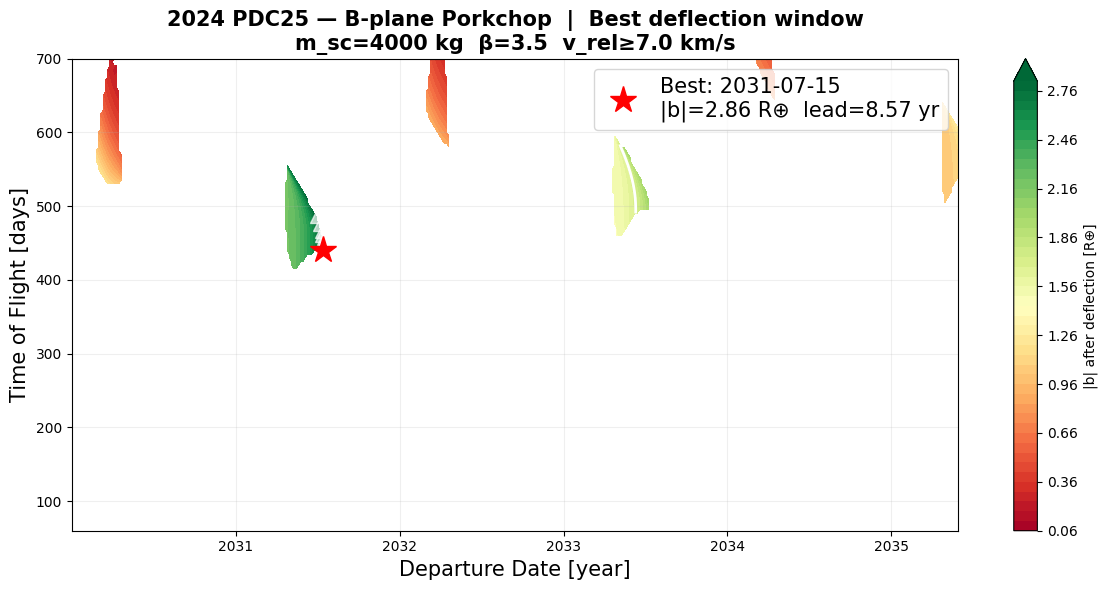

Saved bplane_best.png


In [8]:
# ── Find best deflection dates ────────────────────────────────
import numpy as np
from astropy.time import Time

# Only consider successful misses (b > b_coll)
success_mask = (success_grid == 1.0) & (bplane_grid < 900)  # exclude 999 sentinel

if not success_mask.any():
    print('No successful deflections found in grid!')
else:
    # Get indices sorted by |b| descending (best = largest miss distance)
    b_finite = np.copy(bplane_grid)
    b_finite[~success_mask] = np.nan

    # Flatten and sort
    flat_indices = np.argsort(b_finite.ravel())[::-1]   # descending
    flat_indices = flat_indices[np.isfinite(b_finite.ravel()[flat_indices])]

    print('='*72)
    print(f'TOP 10 DEFLECTION WINDOWS  (m_sc={m_sc:.0f} kg, β={beta_m}, v_rel≥{VREL_MIN_KMS})')
    print('='*72)
    print(f'  {"Rank":>4}  {"Departure":>12}  {"Arrival":>12}  '
          f'{"TOF(d)":>7}  {"C3":>7}  {"v_rel":>7}  '
          f'{"Lead(yr)":>9}  {"b (R⊕)":>9}')
    print('-'*72)

    shown = 0
    for flat_idx in flat_indices:
        if shown >= 10:
            break
        i, j   = np.unravel_index(flat_idx, bplane_grid.shape)
        t_dep  = depart_dates[j]
        tof    = tof_values[i]
        t_arr  = t_dep + tof
        b_Re   = bplane_grid[i, j]
        C3_val = C3_grid[i, j]
        vr_val = vrel_grid[i, j]
        lead   = (mjd_impact - t_arr) / 365.25

        dep_str = Time(t_dep, format='mjd', scale='tdb').iso[:10]
        arr_str = Time(t_arr, format='mjd', scale='tdb').iso[:10]

        print(f'  {shown+1:>4}  {dep_str:>12}  {arr_str:>12}  '
              f'{tof:>7.0f}  {C3_val:>7.2f}  {vr_val:>7.2f}  '
              f'{lead:>9.3f}  {b_Re:>9.3f}')
        shown += 1

    print('='*72)

    # ── Pick the single best ──────────────────────────────────
    best_flat = flat_indices[0]
    bi, bj    = np.unravel_index(best_flat, bplane_grid.shape)

    BEST_DEP_MJD  = depart_dates[bj]
    BEST_ARR_MJD  = depart_dates[bj] + tof_values[bi]
    BEST_TOF      = tof_values[bi]
    BEST_B_Re     = bplane_grid[bi, bj]
    BEST_C3       = C3_grid[bi, bj]
    BEST_VREL     = vrel_grid[bi, bj]
    BEST_LEAD     = (mjd_impact - BEST_ARR_MJD) / 365.25

    best_dep_str  = Time(BEST_DEP_MJD, format='mjd', scale='tdb').iso[:10]
    best_arr_str  = Time(BEST_ARR_MJD, format='mjd', scale='tdb').iso[:10]

    print(f'\nOPTIMAL MISSION DATE:')
    print(f'  Departure  : {best_dep_str}')
    print(f'  Arrival    : {best_arr_str}')
    print(f'  TOF        : {BEST_TOF:.0f} days  ({BEST_TOF/365.25:.2f} yr)')
    print(f'  C3         : {BEST_C3:.2f} km²/s²')
    print(f'  v_rel      : {BEST_VREL:.2f} km/s')
    print(f'  Lead time  : {BEST_LEAD:.3f} yr before impact')
    print(f'  |b|        : {BEST_B_Re:.3f} R⊕  (b_coll={b_coll_Re:.3f} R⊕)')
    print(f'  Margin     : {BEST_B_Re/b_coll_Re:.2f}×  above b_coll')

    # ── Set as CHOSEN for downstream cells ───────────────────
    CHOSEN_DEP_MJD = BEST_DEP_MJD
    CHOSEN_ARR_MJD = BEST_ARR_MJD
    CHOSEN_TOF     = BEST_TOF

    print(f'\n→ CHOSEN_DEP_MJD, CHOSEN_ARR_MJD, CHOSEN_TOF set for downstream cells')

    # ── Plot: mark best point on b-plane porkchop ────────────
    def mjd_to_year(mjd):
        return Time(mjd, format='mjd', scale='tdb').decimalyear

    depart_years = np.array([mjd_to_year(m) for m in depart_dates])
    X, Y = np.meshgrid(depart_years, tof_values)

    bplane_plot = np.clip(bplane_grid, 0, 20)

    fig, ax = plt.subplots(figsize=(12, 6))
    cf = ax.contourf(X, Y, bplane_plot, levels=50, cmap='RdYlGn', extend='max')
    plt.colorbar(cf, ax=ax, label='|b| after deflection [R⊕]')

    # b_coll boundary
    cs = ax.contour(X, Y, bplane_grid,
                    levels=[b_coll_Re], colors='white', linewidths=2.0)
    ax.clabel(cs, fmt=f'b_coll={b_coll_Re:.2f} R⊕', fontsize=15, colors='white')

    # Mark top 10
    for rank, flat_idx in enumerate(flat_indices[:10]):
        ii, jj = np.unravel_index(flat_idx, bplane_grid.shape)
        ax.plot(depart_years[jj], tof_values[ii],
                'w^', ms=8, zorder=9, alpha=0.7)

    # Mark best
    ax.plot(depart_years[bj], BEST_TOF, 'r*', ms=20, zorder=10,
            label=f'Best: {best_dep_str}\n'
                  f'|b|={BEST_B_Re:.2f} R⊕  lead={BEST_LEAD:.2f} yr')

    ax.set_xlabel('Departure Date [year]', fontsize=15)
    ax.set_ylabel('Time of Flight [days]', fontsize=15)
    ax.set_title(
        f'2024 PDC25 — B-plane Porkchop  |  Best deflection window\n'
        f'm_sc={m_sc:.0f} kg  β={beta_m}  v_rel≥{VREL_MIN_KMS} km/s',
        fontsize=15, fontweight='bold'
    )
    ax.legend(fontsize=15, loc='upper right')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('./bplane_best.png', dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved bplane_best.png')

## Cell 7 — Porkchop Plot

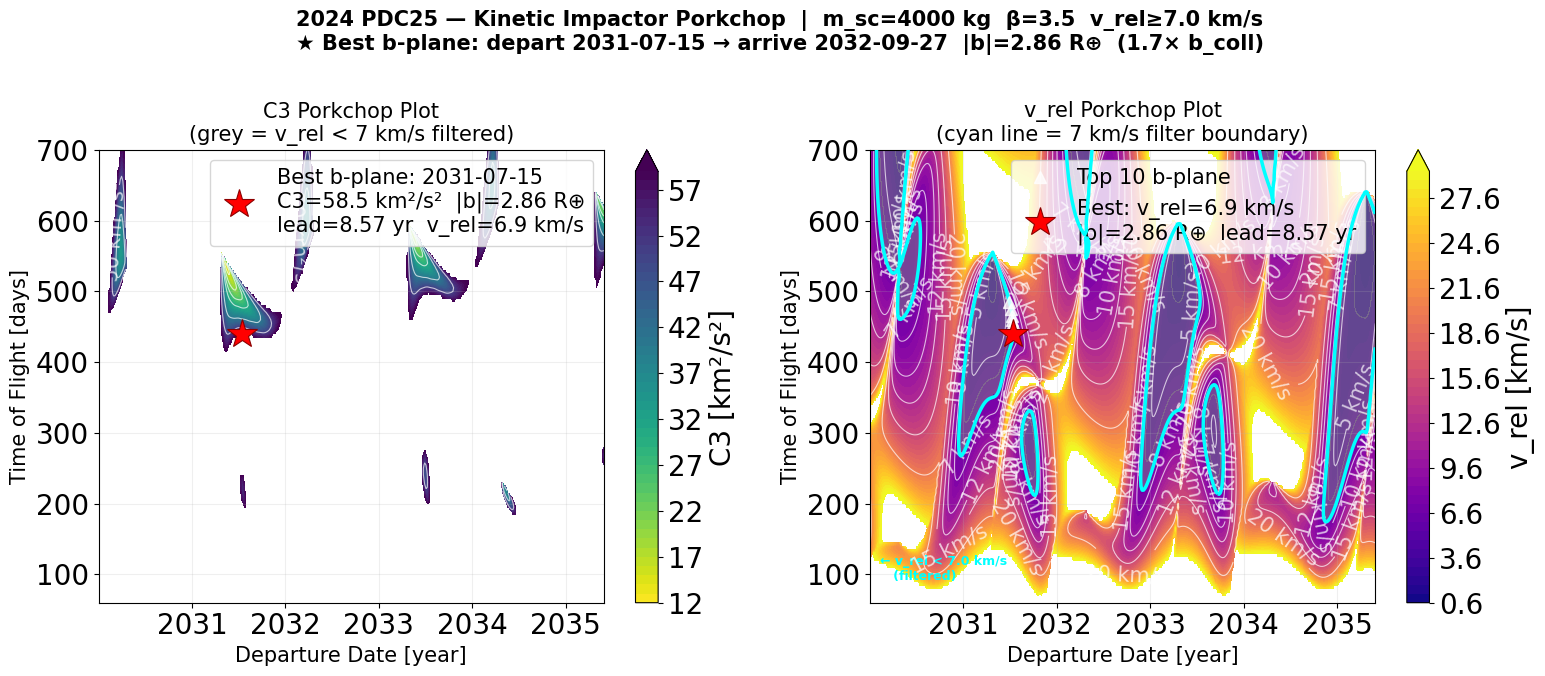

Saved porkchop_with_best_bplane.png


In [9]:
plt.rcParams.update({'font.size': 20})   # raises all default text by 2


# ── Plot standard porkchop with best b-plane result marked ───
def mjd_to_year(mjd):
    return Time(mjd, format='mjd', scale='tdb').decimalyear

depart_years = np.array([mjd_to_year(m) for m in depart_dates])
X, Y = np.meshgrid(depart_years, tof_values)

# Clip for display
C3_plot   = np.copy(C3_grid);   C3_plot[C3_plot > 60]    = np.nan
vrel_plot = np.copy(vrel_grid); vrel_plot[vrel_plot > 30] = np.nan

# Grey out filtered region (v_rel < 7 km/s)
vrel_filter_mask = (vrel_grid < VREL_MIN_KMS) | (~np.isfinite(vrel_grid))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ── LEFT: C3 ─────────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(X, Y, C3_plot, levels=50, cmap='viridis_r', extend='max')
cs = ax.contour(X, Y, C3_plot, levels=[5,10,15,20,25,30,40,50],
                colors='white', linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt='%d km²/s²', fontsize=15, colors='white')
plt.colorbar(cf, ax=ax, label='C3 [km²/s²]')


# Best b-plane point — red star
ax.plot(depart_years[bj], BEST_TOF, 'r*', ms=22, zorder=10,
        markeredgecolor='darkred', markeredgewidth=0.8,
        label=f'Best b-plane: {best_dep_str}\n'
              f'C3={BEST_C3:.1f} km²/s²  |b|={BEST_B_Re:.2f} R⊕\n'
              f'lead={BEST_LEAD:.2f} yr  v_rel={BEST_VREL:.1f} km/s')

ax.set_xlabel('Departure Date [year]', fontsize=15)
ax.set_ylabel('Time of Flight [days]', fontsize=15)
ax.set_title('C3 Porkchop Plot\n(grey = v_rel < 7 km/s filtered)', fontsize=15)
ax.legend(fontsize=15, loc='upper right')
ax.grid(True, alpha=0.2)

# ── RIGHT: v_rel ──────────────────────────────────────────────
ax2 = axes[1]
cf2 = ax2.contourf(X, Y, vrel_plot, levels=50, cmap='plasma', extend='max')
cs2 = ax2.contour(X, Y, vrel_plot, levels=[5, 7, 8, 10, 12, 15, 20],
                  colors='white', linewidths=0.8, alpha=0.7)
ax2.clabel(cs2, fmt='%d km/s', fontsize=15, colors='white')
plt.colorbar(cf2, ax=ax2, label='v_rel [km/s]')

# Grey overlay where v_rel < 7 km/s
vrel_grey = np.copy(vrel_plot)
vrel_grey[~vrel_filter_mask] = np.nan
ax2.contourf(X, Y, vrel_grey, levels=1, colors=['#888888'], alpha=0.5)

# 7 km/s boundary line — prominent
ax2.contour(X, Y, vrel_grid, levels=[VREL_MIN_KMS],
            colors=['cyan'], linewidths=2.5, zorder=8)
# Label it manually
ax2.text(0.02, 0.05, f'← v_rel < {VREL_MIN_KMS} km/s\n   (filtered)',
         transform=ax2.transAxes, fontsize=9,
         color='cyan', fontweight='bold')

# Top 10 b-plane winners
for rank, flat_idx in enumerate(flat_indices[:10]):
    ii, jj = np.unravel_index(flat_idx, bplane_grid.shape)
    ax2.plot(depart_years[jj], tof_values[ii],
             'w^', ms=9, zorder=9, alpha=0.8,
             label='Top 10 b-plane' if rank == 0 else '')

# Best b-plane point
ax2.plot(depart_years[bj], BEST_TOF, 'r*', ms=22, zorder=10,
         markeredgecolor='darkred', markeredgewidth=0.8,
         label=f'Best: v_rel={BEST_VREL:.1f} km/s\n'
               f'|b|={BEST_B_Re:.2f} R⊕  lead={BEST_LEAD:.2f} yr')

ax2.set_xlabel('Departure Date [year]', fontsize=15)
ax2.set_ylabel('Time of Flight [days]', fontsize=15)
ax2.set_title('v_rel Porkchop Plot\n(cyan line = 7 km/s filter boundary)', fontsize=15)
ax2.legend(fontsize=15, loc='upper right')
ax2.grid(True, alpha=0.2)

fig.suptitle(
    f'2024 PDC25 — Kinetic Impactor Porkchop  |  '
    f'm_sc={m_sc:.0f} kg  β={beta_m}  v_rel≥{VREL_MIN_KMS} km/s\n'
    f'★ Best b-plane: depart {best_dep_str} → arrive {best_arr_str}  '
    f'|b|={BEST_B_Re:.2f} R⊕  ({BEST_B_Re/b_coll_Re:.1f}× b_coll)',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig('./porkchop_with_best_bplane.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved porkchop_with_best_bplane.png')

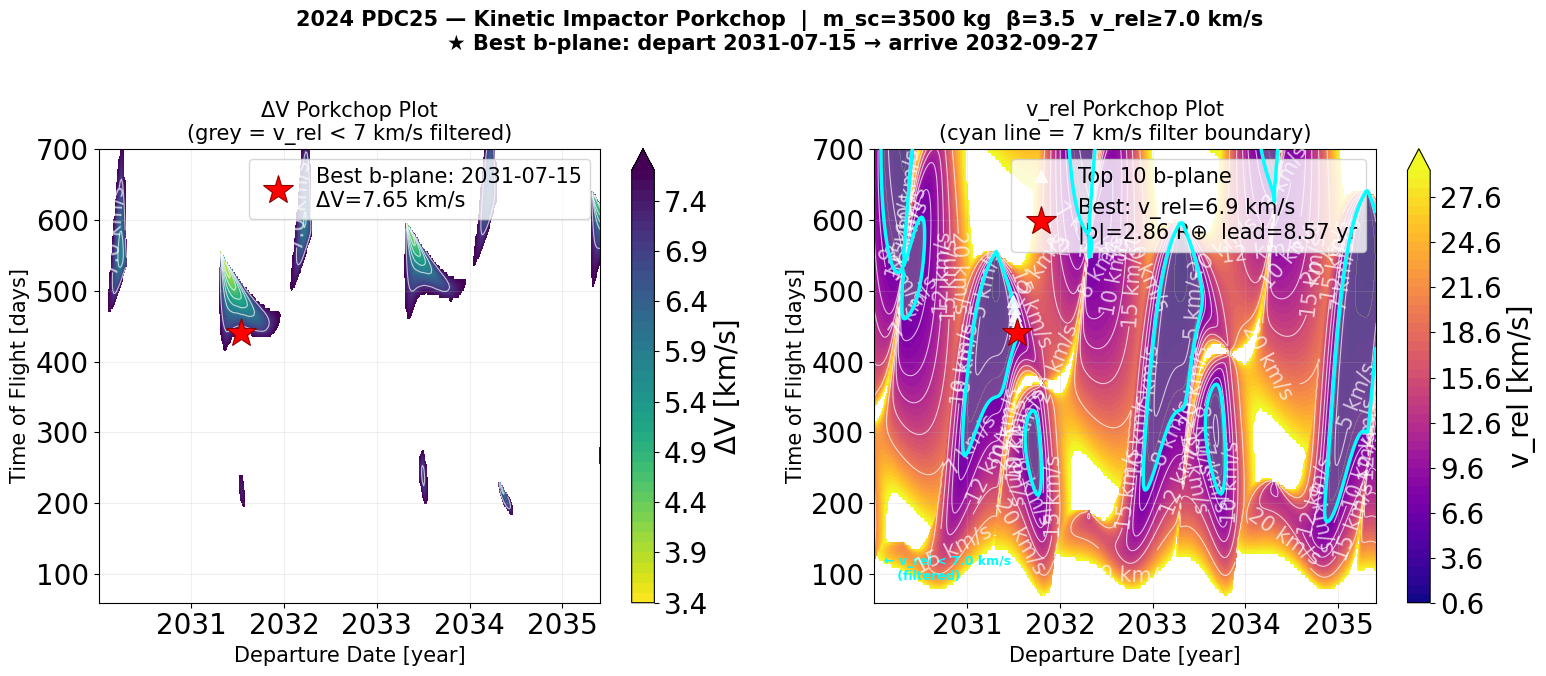

Saved porkchop_with_best_bplane.png


In [22]:
plt.rcParams.update({'font.size': 20})

def mjd_to_year(mjd):
    return Time(mjd, format='mjd', scale='tdb').decimalyear

depart_years = np.array([mjd_to_year(m) for m in depart_dates])
X, Y = np.meshgrid(depart_years, tof_values)

# ── Compute ΔV = sqrt(C3) ─────────────────────────────────────
dv_grid = np.sqrt(np.maximum(C3_grid, 0))          # km/s; clamp negatives to 0
BEST_DV = np.sqrt(max(BEST_C3, 0))                 # scalar for legend

# Clip for display
dv_plot   = np.copy(dv_grid);   dv_plot[dv_plot > np.sqrt(60)] = np.nan   # ~7.75 km/s
vrel_plot = np.copy(vrel_grid); vrel_plot[vrel_plot > 30]       = np.nan

# Grey out filtered region (v_rel < 7 km/s)
vrel_filter_mask = (vrel_grid < VREL_MIN_KMS) | (~np.isfinite(vrel_grid))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# ── LEFT: ΔV ─────────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(X, Y, dv_plot, levels=50, cmap='viridis_r', extend='max')
cs = ax.contour(X, Y, dv_plot,
                levels=[2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 7],   # km/s
                colors='white', linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt='%.1f km/s', fontsize=15, colors='white')
plt.colorbar(cf, ax=ax, label='ΔV [km/s]')

# Best b-plane point — red star
ax.plot(depart_years[bj], BEST_TOF, 'r*', ms=22, zorder=10,
        markeredgecolor='darkred', markeredgewidth=0.8,
        label=f'Best b-plane: {best_dep_str}\n'
              f'ΔV={BEST_DV:.2f} km/s ')
ax.set_xlabel('Departure Date [year]', fontsize=15)
ax.set_ylabel('Time of Flight [days]', fontsize=15)
ax.set_title('ΔV Porkchop Plot\n(grey = v_rel < 7 km/s filtered)', fontsize=15)
ax.legend(fontsize=15, loc='upper right')
ax.grid(True, alpha=0.2)

# ── RIGHT: v_rel ──────────────────────────────────────────────
ax2 = axes[1]
cf2 = ax2.contourf(X, Y, vrel_plot, levels=50, cmap='plasma', extend='max')
cs2 = ax2.contour(X, Y, vrel_plot, levels=[5, 7, 8, 10, 12, 15, 20],
                  colors='white', linewidths=0.8, alpha=0.7)
ax2.clabel(cs2, fmt='%d km/s', fontsize=15, colors='white')
plt.colorbar(cf2, ax=ax2, label='v_rel [km/s]')

# Grey overlay where v_rel < 7 km/s
vrel_grey = np.copy(vrel_plot)
vrel_grey[~vrel_filter_mask] = np.nan
ax2.contourf(X, Y, vrel_grey, levels=1, colors=['#888888'], alpha=0.5)

# 7 km/s boundary line — prominent
ax2.contour(X, Y, vrel_grid, levels=[VREL_MIN_KMS],
            colors=['cyan'], linewidths=2.5, zorder=8)
ax2.text(0.02, 0.05, f'← v_rel < {VREL_MIN_KMS} km/s\n   (filtered)',
         transform=ax2.transAxes, fontsize=9,
         color='cyan', fontweight='bold')

# Top 10 b-plane winners
for rank, flat_idx in enumerate(flat_indices[:10]):
    ii, jj = np.unravel_index(flat_idx, bplane_grid.shape)
    ax2.plot(depart_years[jj], tof_values[ii],
             'w^', ms=9, zorder=9, alpha=0.8,
             label='Top 10 b-plane' if rank == 0 else '')

# Best b-plane point
ax2.plot(depart_years[bj], BEST_TOF, 'r*', ms=22, zorder=10,
         markeredgecolor='darkred', markeredgewidth=0.8,
         label=f'Best: v_rel={BEST_VREL:.1f} km/s\n'
               f'|b|={BEST_B_Re:.2f} R⊕  lead={BEST_LEAD:.2f} yr')
ax2.set_xlabel('Departure Date [year]', fontsize=15)
ax2.set_ylabel('Time of Flight [days]', fontsize=15)
ax2.set_title('v_rel Porkchop Plot\n(cyan line = 7 km/s filter boundary)', fontsize=15)
ax2.legend(fontsize=15, loc='upper right')
ax2.grid(True, alpha=0.2)

fig.suptitle(
    f'2024 PDC25 — Kinetic Impactor Porkchop  |  '
    f'm_sc={m_sc:.0f} kg  β={beta_m}  v_rel≥{VREL_MIN_KMS} km/s\n'
    f'★ Best b-plane: depart {best_dep_str} → arrive {best_arr_str}  ',

    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig('./porkchop_with_best_bplane.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved porkchop_with_best_bplane.png')

## Cell 8 — Pick Mission Dates & Compute ΔV to Asteroid

In [17]:
# ── You can override with a manually chosen date here ────────
# Default: use best from porkchop
CHOSEN_DEP_MJD = BEST_DEP_MJD
CHOSEN_ARR_MJD = BEST_ARR_MJD
CHOSEN_TOF     = BEST_TOF

# ── Re-run Lambert for chosen dates ──────────────────────────
r_earth_dep, v_earth_dep = earth_state_at(CHOSEN_DEP_MJD)
r_ast_arr,   v_ast_arr   = asteroid_state_at(CHOSEN_ARR_MJD)

V1_sc, V2_sc = lambert(r_earth_dep, r_ast_arr, CHOSEN_TOF)

# Launch ΔV
dv_launch_vec = V1_sc - v_earth_dep
dv_launch_kms = np.linalg.norm(dv_launch_vec) * AU_KM / DAY_S
C3_chosen     = dv_launch_kms**2

# Relative velocity at asteroid
dv_rel_vec = V2_sc - v_ast_arr
v_rel_kms  = np.linalg.norm(dv_rel_vec) * AU_KM / DAY_S
v_rel_hat  = dv_rel_vec / np.linalg.norm(dv_rel_vec)   # unit vector

# ── Asteroid physical properties ─────────────────────────────
rho_ast = 1900.0       # kg/m³
R_ast   = 75.0         # m (from OD nongrav_info radius)
m_ast   = (4/3) * np.pi * R_ast**3 * rho_ast

print(f'Asteroid mass = {m_ast:.4e} kg')

# ── Spacecraft ────────────────────────────────────────────────
m_sc   = 3500.0   # kg  (DART-class)
beta_m   = 3.5      # momentum enhancement factor

# ── ΔV imparted to asteroid (momentum transfer) ───────────────
# dv_ast = beta * m_sc * v_rel / m_ast  (in direction of v_rel)
dv_ast_kms  = beta_m * m_sc * v_rel_kms / m_ast
dv_ast_ms   = dv_ast_kms * 1e3
dv_ast_AUday = dv_ast_kms / (AU_KM / DAY_S)

# ΔV vector on asteroid (along spacecraft relative velocity)
dv_ast_vec_AUday = -dv_ast_AUday * v_rel_hat


dep_date = Time(CHOSEN_DEP_MJD, format='mjd', scale='tdb').iso[:10]
arr_date = Time(CHOSEN_ARR_MJD, format='mjd', scale='tdb').iso[:10]
lead_days = mjd_impact - CHOSEN_ARR_MJD

print('='*58)
print('MISSION DESIGN SUMMARY')
print('='*58)
print(f'  Departure date       : {dep_date}')
print(f'  Arrival/intercept    : {arr_date}')
print(f'  Time of flight       : {CHOSEN_TOF:.0f} days  ({CHOSEN_TOF/365.25:.2f} yr)')
print(f'  C3 (launch energy)   : {C3_chosen:.2f} km²/s²')
print(f'  v_rel at intercept   : {v_rel_kms:.2f} km/s')
print(f'  Lead time            : {lead_days:.0f} days  ({lead_days/365.25:.2f} yr)')
print('-'*58)
print(f'  Asteroid mass        : {m_ast:.4e} kg')
print(f'  S/C mass             : {m_sc:.0f} kg')
print(f'  β (momentum factor)  : {beta_m}')
print(f'  ΔV to asteroid       : {dv_ast_ms:.5f} m/s')
print('='*58)

Asteroid mass = 3.3576e+09 kg
MISSION DESIGN SUMMARY
  Departure date       : 2031-07-15
  Arrival/intercept    : 2032-09-27
  Time of flight       : 440 days  (1.20 yr)
  C3 (launch energy)   : 58.51 km²/s²
  v_rel at intercept   : 6.87 km/s
  Lead time            : 3132 days  (8.57 yr)
----------------------------------------------------------
  Asteroid mass        : 3.3576e+09 kg
  S/C mass             : 3500 kg
  β (momentum factor)  : 3.5
  ΔV to asteroid       : 0.02507 m/s


## Cell 9 — B-Plane: Nominal Impact

Get asteroid and Earth states at impact time using GRSS interpolation + SPICE.

In [18]:
# In notebook — load pre-computed nominal b-plane
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)

nom     = bp_data['nominal']
cloud   = bp_data['cloud']

AU_KM       = 149597870.7
R_e_km      = 6371.0
MU_EARTH_KMS = 3.986004418e5

U0_kms    = nom['vInf'] * AU_KM / DAY_S
b0_km     = nom['bMag'] * AU_KM
b_coll_km = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re = b_coll_km / R_e_km
xi0_Re    = nom['xi']   * AU_KM / R_e_km
zeta0_Re  = nom['zeta'] * AU_KM / R_e_km

# 1000-clone uncertainty cloud
xi_cloud   = np.array([c['xi']   for c in cloud]) * AU_KM / R_e_km
zeta_cloud = np.array([c['zeta'] for c in cloud]) * AU_KM / R_e_km

print(f'U∞     = {U0_kms:.4f} km/s')
print(f'|b|    = {b0_km:.4f} km  ({b0_km/R_e_km:.6f} R⊕)')
print(f'b_coll = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')
print(f'ξ      = {xi0_Re:+.6f} R⊕')
print(f'ζ      = {zeta0_Re:+.6f} R⊕')
print(f'Cloud  : {len(xi_cloud)} clones')

U∞     = 8.0936 km/s
|b|    = 4129.1332 km  (0.648114 R⊕)
b_coll = 10868.47 km  (1.7059 R⊕)
ξ      = -0.041982 R⊕
ζ      = +0.646753 R⊕
Cloud  : 1000 clones


## Cell 10 — Deflected B-Plane

Apply ΔV to asteroid at intercept, re-propagate using GRSS, get new b-plane.

In [19]:
from grss import prop, utils
import json
import numpy as np

# ── Load nominal b-plane ──────────────────────────────────────
with open('./data/nominal_bplane.json') as f:
    bp_data = json.load(f)

nom        = bp_data['nominal']
cloud      = bp_data['cloud']

AU_KM        = 149597870.7
DAY_S        = 86400.0
R_e_km       = 6371.0
MU_EARTH_KMS = 3.986004418e5

U0_kms    = nom['vInf'] * AU_KM / DAY_S
b0_km     = nom['bMag'] * AU_KM
b_coll_km = R_e_km * np.sqrt(1 + 2*MU_EARTH_KMS / (R_e_km * U0_kms**2))
b_coll_Re = b_coll_km / R_e_km
xi0_Re    = nom['xi']   * AU_KM / R_e_km
zeta0_Re  = nom['zeta'] * AU_KM / R_e_km
mjd_impact = nom['t_ca']

print('NOMINAL IMPACT B-PLANE:')
print(f'  U∞     = {U0_kms:.4f} km/s')
print(f'  ξ      = {xi0_Re:+.6f} R⊕')
print(f'  ζ      = {zeta0_Re:+.6f} R⊕')
print(f'  |b|    = {b0_km:.4f} km  ({b0_km/R_e_km:.6f} R⊕)')
print(f'  b_coll = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')

# ── Get precise asteroid state at intercept via GRSS ─────────
# Use the daily table but with GRSS's own conversion, not linear interp
r_ast_int, v_ast_int = asteroid_state_at(CHOSEN_ARR_MJD)


# ── Apply ΔV ─────────────────────────────────────────────────
v_ast_deflected = np.array(v_ast_int) + dv_ast_vec_AUday

# ── Convert deflected Cartesian → cometary for GRSS ──────────
cart_defl = list(r_ast_int) + list(v_ast_deflected)
cometary_defl = libgrss.cartesian_to_cometary(CHOSEN_ARR_MJD, cart_defl)
# cometary_to_cartesian returns [e, q, tp, om, w, i]
defl_sol = {
    't' : CHOSEN_ARR_MJD,
    'e' : cometary_defl[0],
    'q' : cometary_defl[1],
    'tp': cometary_defl[2],
    'om': cometary_defl[3],
    'w' : cometary_defl[4],
    'i' : cometary_defl[5],
    'a2': nongrav_info['a2'],   # keep Yarkovsky
}

# ── Propagate deflected orbit with parallel_propagate ─────────
mjd_end_defl = nom['t_ca'] + 30000   # stop at nominal impact epoch

ng_defl = prop.NongravParameters()
ng_defl.a1    = nongrav_info['a1'];  ng_defl.a1Est = False
ng_defl.a2    = nongrav_info['a2'];  ng_defl.a2Est = True
ng_defl.a3    = nongrav_info['a3'];  ng_defl.a3Est = False
ng_defl.alpha = nongrav_info['alpha']
ng_defl.k     = nongrav_info['k']
ng_defl.m     = nongrav_info['m']
ng_defl.n     = nongrav_info['n']
ng_defl.r0_au = nongrav_info['r0_au']

ref_sim_defl = prop.PropSimulation(
    name='2024PDC25_defl',
    t0=CHOSEN_ARR_MJD,
    defaultSpiceBodies=440,
    DEkernelPath=utils.default_kernel_path
)
ref_sim_defl.set_integration_parameters(mjd_end_defl)

result_defl = prop.parallel_propagate(
    defl_sol, ng_defl, ref_sim_defl,
    [defl_sol],   # single clone
    1,
    reconstruct=True
)
# ── Extract ALL close approaches, filter Earth only ───────────
all_cas = result_defl[0][0]
print(f'\nAll close approaches found: {len(all_cas)}')
for i, ca in enumerate(all_cas):
    yr = Time(ca.t, format='mjd').decimalyear
    b  = ca.bMag * AU_KM / R_e_km
    print(f'  [{i}] body={ca.centralBody:6s}  year={yr:.4f}  '
          f'|b|={b:.4f} R⊕  impact={ca.impact}')

# ── Helper: get worst Earth-only close approach ───────────────
def get_worst_earth_ca(all_cas):
    earth_cas = [ca for ca in all_cas if ca.centralBody == 'Earth']
    if len(earth_cas) == 0:
        return None
    return min(earth_cas, key=lambda ca: ca.bMag)

# ── Use worst Earth CA for assessment ────────────────────────
worst = get_worst_earth_ca(all_cas)

if worst is None:
    print('\n✓ No Earth close approaches — fully deflected!')
    b_d_Re = 999.0
    xi_d_Re = zeta_d_Re = 0.0
else:
    xi_d_Re   = worst.opik.x * AU_KM / R_e_km
    zeta_d_Re = worst.opik.y * AU_KM / R_e_km
    b_d_km    = worst.bMag * AU_KM
    b_d_Re    = b_d_km / R_e_km
    worst_yr  = Time(worst.t, format='mjd').decimalyear

    print('\n' + '='*50)
    print('DEFLECTED B-PLANE (worst Earth CA):')
    print('='*50)
    print(f'  Year of worst CA     : {worst_yr:.4f}')
    print(f'  ξ (deflected)        = {xi_d_Re:+.4f} R⊕')
    print(f'  ζ (deflected)        = {zeta_d_Re:+.4f} R⊕')
    print(f'  |b| deflected        = {b_d_km:.2f} km  ({b_d_Re:.4f} R⊕)')
    print(f'  b_coll               = {b_coll_km:.2f} km  ({b_coll_Re:.4f} R⊕)')
    print('-'*50)
    print(f'  Δξ                   = {xi_d_Re   - xi0_Re:+.4f} R⊕')
    print(f'  Δζ                   = {zeta_d_Re - zeta0_Re:+.4f} R⊕')
    print(f'  Δ|b|                 = {b_d_Re    - b0_km/R_e_km:+.4f} R⊕')
    print('-'*50)
    if b_d_Re > b_coll_Re:
        print(f'  ✓ MISS — deflection SUCCESSFUL')
        print(f'    |b| = {b_d_Re:.2f} R⊕  >  b_coll = {b_coll_Re:.2f} R⊕')
    else:
        print(f'  ✗ STILL IMPACTS — |b| = {b_d_Re:.2f} R⊕  <  b_coll = {b_coll_Re:.2f} R⊕')
        print(f'    → Try: increase m_sc, increase β, or choose earlier intercept')
    print('='*50)

NOMINAL IMPACT B-PLANE:
  U∞     = 8.0936 km/s
  ξ      = -0.041982 R⊕
  ζ      = +0.646753 R⊕
  |b|    = 4129.1332 km  (0.648114 R⊕)
  b_coll = 10868.47 km  (1.7059 R⊕)
Parallel propagation took 00 minute(s) and 0.420843 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 0.009212 seconds

All close approaches found: 4
  [0] body=Earth   year=2041.3115  |b|=2.5823 R⊕  impact=False
  [1] body=Moon    year=2041.3127  |b|=27.6211 R⊕  impact=False
  [2] body=Earth   year=2088.1869  |b|=2270.6182 R⊕  impact=False
  [3] body=Earth   year=2107.4647  |b|=1810.3800 R⊕  impact=False

DEFLECTED B-PLANE (worst Earth CA):
  Year of worst CA     : 2041.3115
  ξ (deflected)        = -0.0354 R⊕
  ζ (deflected)        = +2.5820 R⊕
  |b| deflected        = 16451.54 km  (2.5823 R⊕)
  b_coll               = 10868.47 km  (1.7059 R⊕)
--------------------------------------------------
  Δξ                   = +0.0066 R⊕
  Δζ                   = +1.9353 R⊕
  Δ|b|                 = +1.9341 R⊕
--------------------------------------------------
  ✓ MISS — deflection SUCCESSFUL
    |b| = 2.58 R⊕  >  b_coll = 1.71 R⊕


## Cell 11 — B-Plane Plot

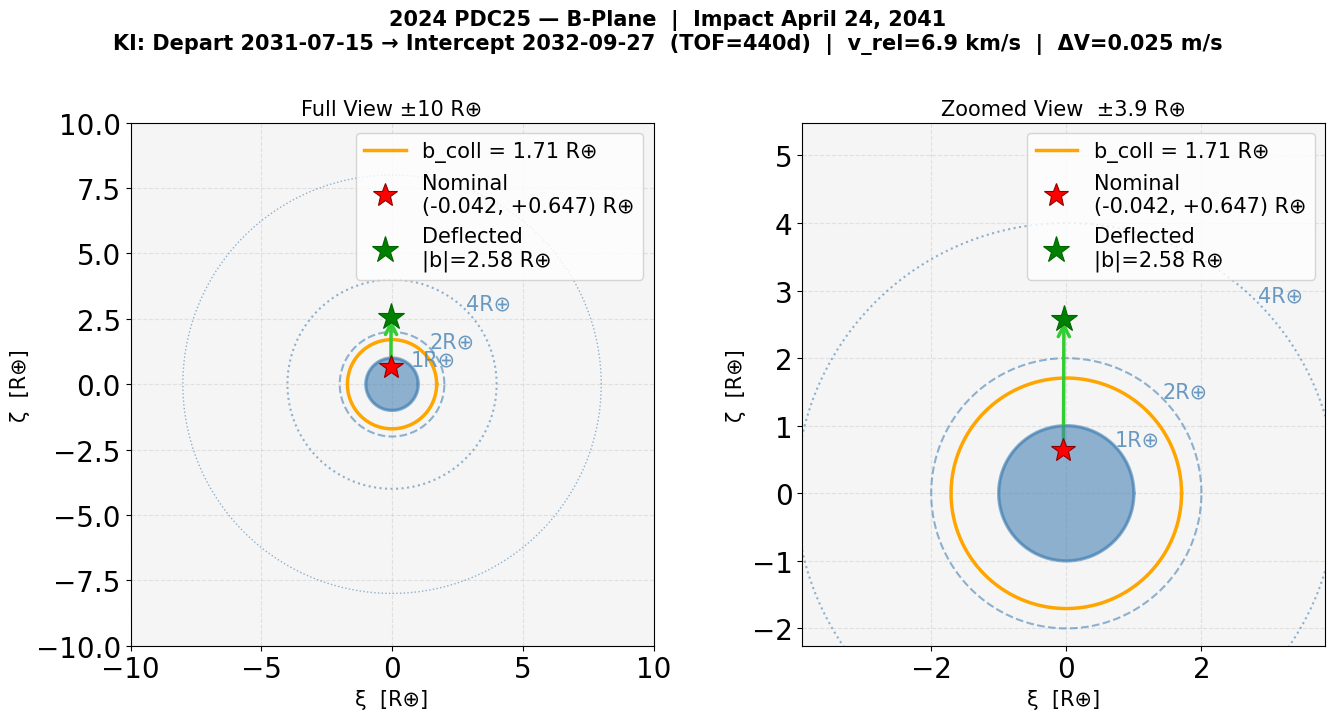

Saved pdr_bplane.png


In [13]:
plt.rcParams.update({'font.size': 20})   # raises all default text by 2

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
theta = np.linspace(0, 2*np.pi, 400)

for ax in axes:
    ax.set_facecolor('#f5f5f5')
    ax.grid(True, alpha=0.3, linestyle='--')

    # Reference circles
    for nr, ls, lw in [(1,'-',2.5),(2,'--',1.5),(4,':',1.5),(8,':',1.0)]:
        ax.plot(nr*np.cos(theta), nr*np.sin(theta),
                ls=ls, lw=lw, color='steelblue', alpha=0.6)
        if nr <= 4:
            ax.text(nr*0.71, nr*0.71, f'{nr}R⊕', fontsize=15,
                    color='steelblue', alpha=0.8)

    # b_coll circle
    ax.plot(b_coll_Re*np.cos(theta), b_coll_Re*np.sin(theta),
            '-', lw=2.5, color='orange',
            label=f'b_coll = {b_coll_Re:.2f} R⊕')

    # Earth
    ax.add_patch(plt.Circle((0,0), 1.0, color='steelblue', alpha=0.6, zorder=4))

    # Nominal impact
    ax.plot(xi0_Re, zeta0_Re, 'r*', ms=18, zorder=9,
            markeredgecolor='darkred', markeredgewidth=0.8,
            label=f'Nominal\n({xi0_Re:+.3f}, {zeta0_Re:+.3f}) R⊕')

    # Deflected
    ax.plot(xi_d_Re, zeta_d_Re, 'g*', ms=20, zorder=10,
            markeredgecolor='darkgreen', markeredgewidth=0.8,
            label=f'Deflected\n|b|={b_d_Re:.2f} R⊕')

    # Arrow
    ax.annotate('',
                xy=(xi_d_Re, zeta_d_Re),
                xytext=(xi0_Re, zeta0_Re),
                arrowprops=dict(arrowstyle='->', color='limegreen',
                                lw=2.5, mutation_scale=20))

    ax.set_aspect('equal')
    ax.set_xlabel('ξ  [R⊕]', fontsize=15)
    ax.set_ylabel('ζ  [R⊕]', fontsize=15)

# Full view
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10)
axes[0].set_title('Full View ±10 R⊕', fontsize=15)
axes[0].legend(fontsize=15, loc='upper right')

# Zoomed view
pad = max(3.0, abs(xi_d_Re - xi0_Re)*2, abs(zeta_d_Re - zeta0_Re)*2)
cx  = (xi0_Re + xi_d_Re) / 2
cy  = (zeta0_Re + zeta_d_Re) / 2
axes[1].set_xlim(cx-pad, cx+pad); axes[1].set_ylim(cy-pad, cy+pad)
axes[1].set_title(f'Zoomed View  ±{pad:.1f} R⊕', fontsize=15)
axes[1].legend(fontsize=15, loc='upper right')

fig.suptitle(
    f'2024 PDC25 — B-Plane  |  Impact April 24, 2041\n'
    f'KI: Depart {dep_date} → Intercept {arr_date}  '
    f'(TOF={CHOSEN_TOF:.0f}d)  |  '
    f'v_rel={v_rel_kms:.1f} km/s  |  ΔV={dv_ast_ms:.3f} m/s',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('./pdr_bplane.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved pdr_bplane.png')

## Cell 12 — PDR Summary Table

In [14]:
print('='*60)
print('PDR SUMMARY — 2024 PDC25 Kinetic Impactor')
print('='*60)
print(f'  Impact date          : April 24, 2041')
print(f'  Departure date       : {dep_date}')
print(f'  Intercept date       : {arr_date}')
print(f'  Time of flight       : {CHOSEN_TOF:.0f} d  ({CHOSEN_TOF/365.25:.1f} yr)')
print(f'  Lead time            : {lead_days:.0f} d  ({lead_days/365.25:.1f} yr)')
print('-'*60)
print(f'  C3 (launch energy)   : {C3_chosen:.2f} km²/s²')
print(f'  v_rel at intercept   : {v_rel_kms:.2f} km/s')
print(f'  S/C mass             : {m_sc:.0f} kg')
print(f'  β (ejecta factor)    : {beta_m}')
print(f'  ΔV to asteroid       : {dv_ast_ms:.4f} m/s')
print('-'*60)
print(f'  U∞                   : {U0_kms:.3f} km/s')
print(f'  b_coll               : {b_coll_km:.1f} km  ({b_coll_Re:.3f} R⊕)')
print(f'  Nominal |b|          : {b0_km:.2f} km  ({b0_km/R_e_km:.5f} R⊕)')
print(f'  Deflected |b|        : {b_d_km:.2f} km  ({b_d_Re:.4f} R⊕)')
outcome = '✓ MISS' if b_d_Re > b_coll_Re else '✗ STILL IMPACTING'
print(f'  Outcome              : {outcome}')
print('='*60)

PDR SUMMARY — 2024 PDC25 Kinetic Impactor
  Impact date          : April 24, 2041
  Departure date       : 2031-07-15
  Intercept date       : 2032-09-27
  Time of flight       : 440 d  (1.2 yr)
  Lead time            : 3132 d  (8.6 yr)
------------------------------------------------------------
  C3 (launch energy)   : 58.51 km²/s²
  v_rel at intercept   : 6.87 km/s
  S/C mass             : 3500 kg
  β (ejecta factor)    : 3.5
  ΔV to asteroid       : 0.0251 m/s
------------------------------------------------------------
  U∞                   : 8.094 km/s
  b_coll               : 10868.5 km  (1.706 R⊕)
  Nominal |b|          : 4129.13 km  (0.64811 R⊕)
  Deflected |b|        : 16451.54 km  (2.5823 R⊕)
  Outcome              : ✓ MISS


In [15]:
launch_vehicles = {
    'Falcon 9 Heavy Expendable' : 14000,   # kg UPSM
    'Falcon 9 Heavy Recoverable':  5000,
    'Delta IV Heavy'            : 12000,
    'Atlas 551'                 :  8000,
    'SLS Block 1 (5m fairing)'  : 28000,
    'SLS Block 1B'              : 48000,
}
PAF_mass = 1000   # kg (adapter)

print(f'C3 = {best_C3:.2f} km²/s²')
print(f'b_coll = {b_coll_Re:.4f} R⊕')
print(f'Min β for success at current m_sc={m_sc:.0f} kg: {b_coll_Re/b_d_Re*beta_m:.2f}')
print()
print(f'{"Vehicle":<30} {"m_sc (kg)":>10} {"ΔV (m/s)":>10} {"b at β=2":>10} {"b at β=3":>10}  Status β=2')
print('-'*85)

for vehicle, upsm in launch_vehicles.items():
    m_sc_v = upsm - PAF_mass
    for beta_test, label in [(2.0, 'β=2'), (3.0, 'β=3')]:
        dv_ms = beta_test * m_sc_v * (v_rel_kms * 1e3) / m_ast
        # Scale b linearly from baseline
        b_est = b_d_Re * (m_sc_v / m_sc) * (beta_test / beta_m)
        
    dv_b2 = 2.0 * m_sc_v * (v_rel_kms * 1e3) / m_ast
    dv_b3 = 3.0 * m_sc_v * (v_rel_kms * 1e3) / m_ast
    b_b2  = b_d_Re * (m_sc_v / m_sc) * (2.0 / beta_m)
    b_b3  = b_d_Re * (m_sc_v / m_sc) * (3.0 / beta_m)
    flag  = '✓ MISS' if b_b2 > b_coll_Re else '✗ IMPACT'
    print(f'{vehicle:<30} {m_sc_v:>10.0f} {dv_b3*1000:>10.4f} '
          f'{b_b2:>10.3f} {b_b3:>10.3f}  {flag}')

print('-'*85)
print(f'{"b_coll threshold":>52} {b_coll_Re:>10.4f} R⊕')

NameError: name 'best_C3' is not defined